# Supervised – PneumoniaMNIST: EDA & pre-processing rationale

This notebook analyses **PneumoniaMNIST** (MedMNIST): 28×28 **grayscale** chest X-ray–style patches with **binary** labels (normal vs. pneumonia).

**Goals** (CVRIE subject): justify dataset choice, characterise **class balance**, **value range / normalisation**, and obvious **outliers** before modelling in `02_models_evaluation.ipynb`.

**Data layout** (same as `export_pneumonia_png.py` at repo root):
- `../pneumoniamnist/train_images.npy`, `train_labels.npy` (and `val` / `test`).

In [9]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8")

_cwd_r = Path.cwd().resolve()
DATA_DIR = next(
    (p for p in (_cwd_r / "pneumoniamnist", _cwd_r.parent / "pneumoniamnist") if p.is_dir()),
    _cwd_r.parent / "pneumoniamnist",
)
FIG_DIR = DATA_DIR.parent / "supervised" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# MedMNIST Pneumonia: 0 = normal, 1 = pneumonia
LABEL_NAMES = {0: "normal (0)", 1: "pneumonia (1)"}


def save_current_fig(filename: str) -> None:
    path = FIG_DIR / filename
    plt.gcf().savefig(path, dpi=160, bbox_inches="tight")
    print(f"Saved: {path}")


def load_split(name: str) -> tuple[np.ndarray, np.ndarray]:
    X = np.load(DATA_DIR / f"{name}_images.npy")
    y = np.load(DATA_DIR / f"{name}_labels.npy").astype(np.int64).ravel()
    return X, y


for split in ("train", "val", "test"):
    assert (DATA_DIR / f"{split}_images.npy").exists(), f"Missing {split}_images.npy under {DATA_DIR}"

DATA_DIR.resolve()

PosixPath('/Users/karma/code/epitech/2_year/G-AIA-400-LYN-4-1-cvrie-3/pneumoniamnist')

## 1) Dataset summary & class distribution

We only use **images** and **labels** (subject: trim extra fields; model must not use metadata).
Official splits avoid **leakage** between train / validation / test.

train  X=(4708, 28, 28)  dtype=uint8  y=(4708,)  labels=[0 1]
val    X=(524, 28, 28)  dtype=uint8  y=(524,)  labels=[0 1]
test   X=(624, 28, 28)  dtype=uint8  y=(624,)  labels=[0 1]


,normal (0),pneumonia (1),total,pct_pneumonia
split,,,,
test,234,390,624,62.50
train,1214,3494,4708,74.21
val,135,389,524,74.24


Saved: /Users/karma/code/epitech/2_year/G-AIA-400-LYN-4-1-cvrie-3/supervised/figures/pneumonia_class_counts_per_split.png


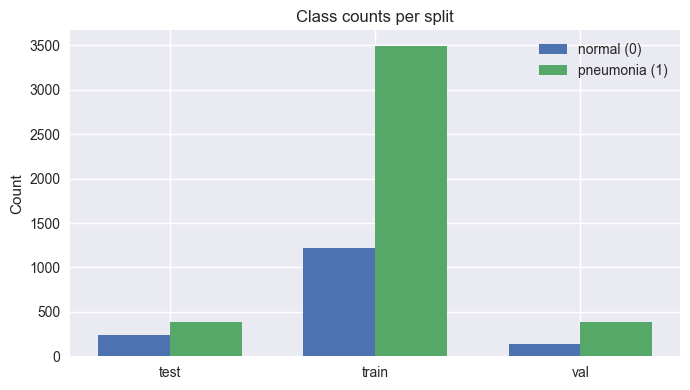

In [10]:
splits = {}
for name in ("train", "val", "test"):
    X, y = load_split(name)
    splits[name] = (X, y)
    print(f"{name:5s}  X={X.shape}  dtype={X.dtype}  y={y.shape}  labels={np.unique(y)}")

rows = []
for name, (_, y) in splits.items():
    vc = pd.Series(y).value_counts().sort_index()
    for lab, c in vc.items():
        rows.append({"split": name, "label": int(lab), "count": int(c)})
counts_df = pd.DataFrame(rows)
pivot = counts_df.pivot(index="split", columns="label", values="count").fillna(0).astype(int)
pivot.columns = [LABEL_NAMES.get(int(c), str(c)) for c in pivot.columns]
pivot["total"] = pivot.sum(axis=1)
pivot["pct_pneumonia"] = (pivot[LABEL_NAMES[1]] / pivot["total"] * 100).round(2)
display(pivot)

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(pivot))
w = 0.35
c0 = pivot[LABEL_NAMES[0]].values
c1 = pivot[LABEL_NAMES[1]].values
ax.bar(x - w / 2, c0, w, label=LABEL_NAMES[0])
ax.bar(x + w / 2, c1, w, label=LABEL_NAMES[1])
ax.set_xticks(x)
ax.set_xticklabels(pivot.index)
ax.set_ylabel("Count")
ax.legend()
ax.set_title("Class counts per split")
plt.tight_layout()
save_current_fig("pneumonia_class_counts_per_split.png")
plt.show()

## 2) Visual sanity check

Random **training** examples per class (fixed seed for reproducibility).

Saved: /Users/karma/code/epitech/2_year/G-AIA-400-LYN-4-1-cvrie-3/supervised/figures/pneumonia_sample_grids.png


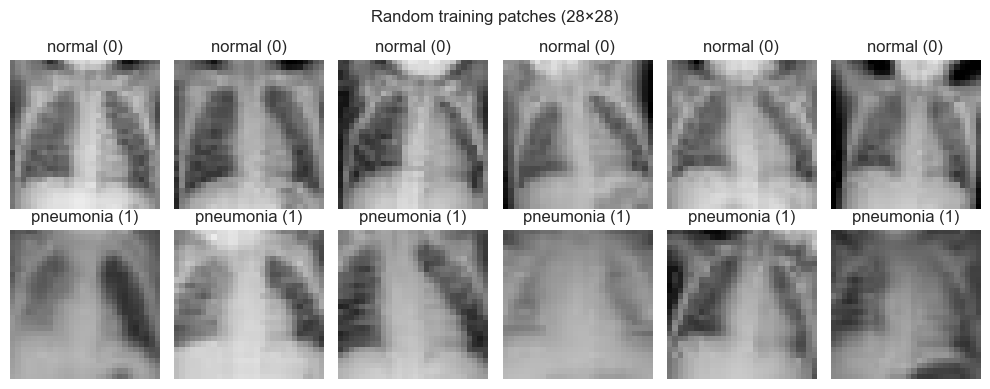

In [11]:
rng = np.random.default_rng(42)
X_tr, y_tr = splits["train"]
fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for r, lab in enumerate((0, 1)):
    idx = np.where(y_tr == lab)[0]
    pick = rng.choice(idx, size=axes.shape[1], replace=False)
    for c, j in enumerate(pick):
        ax = axes[r, c]
        ax.imshow(np.squeeze(X_tr[j]), cmap="gray", vmin=0, vmax=255)
        ax.set_title(LABEL_NAMES[lab])
        ax.axis("off")
plt.suptitle("Random training patches (28×28)")
plt.tight_layout()
save_current_fig("pneumonia_sample_grids.png")
plt.show()

## 3) Pixel intensities & normalisation

Subject expectation: **normalise** inputs when scales vary. Here pixels are **uint8** in \[0, 255\]; we use **\(x/255\)** so values lie in \[0, 1\] (example: 233/255 ≈ 0.913).

We check per-image mean intensity as a simple **outlier screen** (extreme brightness/darkness might indicate bad crops—alerts for manual review, not automatic removal unless justified).

min=0 max=255 dtype=uint8
Saved: /Users/karma/code/epitech/2_year/G-AIA-400-LYN-4-1-cvrie-3/supervised/figures/pneumonia_pixel_histogram.png


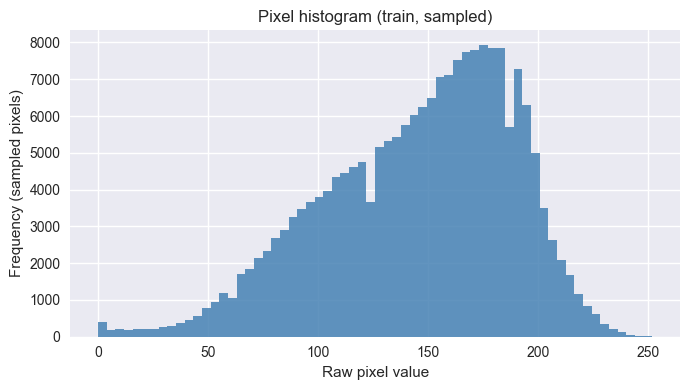

Saved: /Users/karma/code/epitech/2_year/G-AIA-400-LYN-4-1-cvrie-3/supervised/figures/pneumonia_per_image_mean_std.png


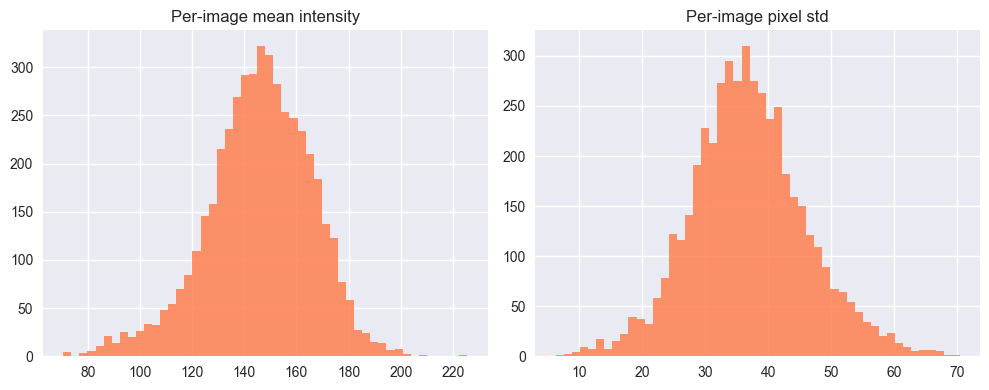

Per-image mean intensity 1–99%: [90.30, 188.39]


In [12]:
X_tr_flat = X_tr.reshape(len(X_tr), -1).astype(np.float64)
print(f"min={X_tr.min()} max={X_tr.max()} dtype={X_tr.dtype}")

sample_pix = rng.choice(X_tr_flat.ravel(), size=min(200_000, X_tr_flat.size), replace=True)
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(sample_pix, bins=64, color="steelblue", alpha=0.85)
ax.set_xlabel("Raw pixel value")
ax.set_ylabel("Frequency (sampled pixels)")
ax.set_title("Pixel histogram (train, sampled)")
plt.tight_layout()
save_current_fig("pneumonia_pixel_histogram.png")
plt.show()

per_mean = X_tr_flat.mean(axis=1)
per_std = X_tr_flat.std(axis=1)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, vals, title in zip(
    axes,
    (per_mean, per_std),
    ("Per-image mean intensity", "Per-image pixel std"),
):
    ax.hist(vals, bins=50, color="coral", alpha=0.85)
    ax.set_title(title)
plt.tight_layout()
save_current_fig("pneumonia_per_image_mean_std.png")
plt.show()

q_lo, q_hi = np.percentile(per_mean, [1, 99])
print(f"Per-image mean intensity 1–99%: [{q_lo:.2f}, {q_hi:.2f}]")

## 4) Conclusions (EDA → preprocessing)

- **Representation**: Single-channel 28×28; model inputs will be **flattened 784-d** vectors after **\(x/255\)** scaling (implemented in notebook 02 and in `train_classify_pneumonia.py`).
- **Imbalance**: If pneumonia ≠ normal counts, we compensate in modelling with **`class_weight='balanced'`** (and document metrics beyond accuracy).
- **Outliers**: No strong evidence of corrupt images from mean/std histograms alone; we **do not drop** rows without a stricter rule, to stay retraceable.
- **Next**: `02_models_evaluation.ipynb` — compare several sklearn classifiers, loss, and proper train/val/test protocol.